# 07. Encouragement Designs

An encouragement design is a randomized experiment where the randomized assignment does not force treatment. Instead, assignment encourages, enables, or makes treatment easier. Some encouraged units take up the treatment; some do not. Some unencouraged units may still find their way into treatment.

This is one of the most useful designs in industry because many product, operations, and policy interventions cannot be forced ethically or practically. We can randomize an invitation, onboarding slot, discount, reminder, eligibility message, implementation support, queue priority, or recommendation, then use that randomized encouragement as an instrument for actual treatment receipt.

The estimands are different from a standard A/B test. The randomized encouragement gives an intention-to-treat effect of the encouragement. With additional assumptions, it also gives a complier average causal effect: the effect of treatment for units whose treatment status changed because of the encouragement.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why encouragement designs are useful when treatment uptake is voluntary.
- Distinguish assignment, encouragement, treatment receipt, and outcome.
- Estimate the intention-to-treat effect of the encouragement.
- Estimate the first stage: the effect of encouragement on treatment uptake.
- Estimate the complier average causal effect using the Wald ratio and 2SLS.
- Understand one-sided and two-sided noncompliance.
- Diagnose why as-treated comparisons are biased.
- Evaluate first-stage strength as a design property.
- Recognize exclusion-restriction failures created by overpowered encouragements.
- Translate an encouragement experiment into an industry readout.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from linearmodels.iv import IV2SLS

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def fit_ols(data, outcome, treatment, controls=None):
    controls = controls or []
    X = sm.add_constant(data[[treatment] + controls], has_constant="add")
    return sm.OLS(data[outcome], X).fit(cov_type="HC1")


def fit_assignment_model(data, outcome, assignment, controls=None):
    controls = controls or []
    X = sm.add_constant(data[[assignment] + controls], has_constant="add")
    return sm.OLS(data[outcome], X).fit(cov_type="HC1")


def coefficient_row(label, model, term):
    estimate = float(model.params[term])
    se = float(model.bse[term])
    return {
        "estimand_or_model": label,
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": float(model.pvalues[term]),
    }


def wald_estimator(data, outcome, treatment, assignment):
    means = data.groupby(assignment)[[outcome, treatment]].mean()
    itt_outcome = means.loc[1, outcome] - means.loc[0, outcome]
    first_stage = means.loc[1, treatment] - means.loc[0, treatment]
    return {
        "itt_outcome": float(itt_outcome),
        "first_stage": float(first_stage),
        "cace": float(itt_outcome / first_stage),
    }


def fit_iv2sls(data, outcome, treatment, assignment, controls=None):
    controls = controls or []
    rhs_controls = " + ".join(controls)
    if rhs_controls:
        formula = f"{outcome} ~ 1 + {rhs_controls} + [{treatment} ~ {assignment}]"
    else:
        formula = f"{outcome} ~ 1 + [{treatment} ~ {assignment}]"
    return IV2SLS.from_formula(formula, data=data).fit(cov_type="robust")


def iv_row(label, result, treatment):
    ci = result.conf_int().loc[treatment]
    return {
        "estimand_or_model": label,
        "estimate": float(result.params[treatment]),
        "std_error": float(result.std_errors[treatment]),
        "ci_low": float(ci.iloc[0]),
        "ci_high": float(ci.iloc[1]),
        "p_value": float(result.pvalues[treatment]),
    }


def plot_estimate_table(table, title, reference=None):
    plot_table = table.dropna(subset=["estimate"]).copy().reset_index(drop=True)
    y = np.arange(len(plot_table))

    fig, ax = plt.subplots(figsize=(9, max(3.8, 0.55 * len(plot_table) + 1.5)))
    for i, row in plot_table.iterrows():
        if np.isfinite(row.get("ci_low", np.nan)) and np.isfinite(row.get("ci_high", np.nan)):
            ax.errorbar(
                row["estimate"],
                y[i],
                xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
                fmt="o",
                capsize=4,
                color="#2563eb",
                ecolor="#93c5fd",
            )
        else:
            ax.scatter(row["estimate"], y[i], color="#2563eb", s=45)

    if reference is not None:
        ax.axvline(reference, color="#16a34a", linestyle="--", linewidth=1.5, label="Reference")
        ax.legend()
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_table["estimand_or_model"])
    ax.invert_yaxis()
    ax.set_xlabel("Estimated effect")
    ax.set_title(title)
    return fig, ax

## 1. Why Encouragement Designs Matter

A standard experiment randomizes treatment. An encouragement design randomizes access, invitation, information, priority, or support. The randomized assignment is still valuable because it creates exogenous variation in treatment uptake.

Examples:

- Randomly invite some customers to a beta feature.
- Randomly offer priority onboarding for a complex AI workflow.
- Randomly send a reminder to complete a setup step.
- Randomly assign account managers a prompt to recommend a product.
- Randomly offer logistics support for a marketplace seller program.
- Randomly give some eligible users a voucher or subsidy.

Encouragement designs appear in program evaluation, medicine, education, and economics. The design is closely related to randomized consent and Zelen-style pragmatic trial ideas, where randomization can precede an offer or consent step (Homer, 2002; Simon et al., 2021). In causal inference, the key connection is that random assignment can serve as an instrument for actual treatment receipt, giving a complier average causal effect under the IV assumptions (Imbens & Angrist, 1994; Angrist et al., 1996).

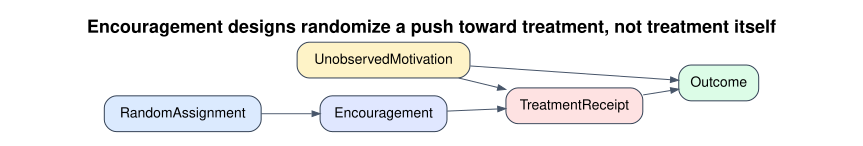

In [3]:
make_dag(
    edges=[
        ("RandomAssignment", "Encouragement"),
        ("Encouragement", "TreatmentReceipt"),
        ("TreatmentReceipt", "Outcome"),
        ("UnobservedMotivation", "TreatmentReceipt"),
        ("UnobservedMotivation", "Outcome"),
    ],
    title="Encouragement designs randomize a push toward treatment, not treatment itself",
    node_colors={
        "RandomAssignment": "#dbeafe",
        "Encouragement": "#e0e7ff",
        "TreatmentReceipt": "#fee2e2",
        "Outcome": "#dcfce7",
        "UnobservedMotivation": "#fef3c7",
    },
)

The randomized encouragement breaks the link between unobserved motivation and the push toward treatment. Actual treatment receipt can still be selective, which is why as-treated comparisons are not enough.

## 2. Assignment, Treatment, and Compliance

Let $Z_i$ be randomized encouragement assignment, $D_i$ be actual treatment receipt, and $Y_i$ be the outcome.

The intention-to-treat effect of the encouragement is:

$$
ITT_Y = E[Y_i \mid Z_i=1] - E[Y_i \mid Z_i=0]
$$

The first stage is:

$$
ITT_D = E[D_i \mid Z_i=1] - E[D_i \mid Z_i=0]
$$

The complier average causal effect, also called CACE or LATE, is:

$$
CACE = \frac{ITT_Y}{ITT_D}
$$

This ratio is the same Wald logic as the previous instrumental-variables notebook. The interpretation changes from "effect of assignment" to "effect of treatment for units whose treatment receipt was changed by the assignment."

## 3. Running Example: Priority AI Copilot Onboarding

Suppose a SaaS company wants to estimate the effect of adopting an AI copilot workflow on renewal margin. The product team cannot force accounts to adopt the workflow. Instead, it randomly offers some accounts a priority onboarding invite.

- Assignment $Z$: priority onboarding invite.
- Treatment $D$: actually adopted the AI copilot workflow.
- Outcome $Y$: 90-day renewal margin.
- Problem: motivated accounts are more likely to adopt and more likely to renew.
- Design: randomize the invite, then use invite assignment as the instrument for adoption.

This is a two-sided noncompliance setting: some invited accounts decline, and some non-invited accounts adopt organically.

In [4]:
def simulate_encouragement_data(
    n=15000,
    seed=7707,
    encouragement_strength=1.0,
    direct_offer_effect=0.0,
):
    rng = np.random.default_rng(seed)

    account_size = rng.lognormal(mean=4.1, sigma=0.50, size=n)
    baseline_usage = rng.normal(50, 12, size=n)
    risk_score = rng.normal(0, 1, size=n)
    enterprise_probability = sigmoid(
        -0.3 + 0.45 * (account_size - account_size.mean()) / account_size.std()
    )
    enterprise_plan = rng.binomial(1, enterprise_probability, size=n)
    unobserved_motivation = rng.normal(0, 1, size=n)

    priority_invite = np.repeat([0, 1], n // 2)
    rng.shuffle(priority_invite)

    latent_adoption_without_invite = (
        -1.4
        + 0.018 * (baseline_usage - 50)
        + 0.35 * enterprise_plan
        - 0.20 * risk_score
        + 0.90 * unobserved_motivation
    )
    latent_adoption_with_invite = latent_adoption_without_invite + encouragement_strength

    p_without_invite = sigmoid(latent_adoption_without_invite)
    p_with_invite = sigmoid(latent_adoption_with_invite)
    adoption_threshold = rng.uniform(0, 1, size=n)

    d0 = (p_without_invite > adoption_threshold).astype(int)
    d1 = (p_with_invite > adoption_threshold).astype(int)
    adopted_copilot = np.where(priority_invite == 1, d1, d0)

    principal_stratum = np.where(
        (d0 == 0) & (d1 == 0),
        "never-taker",
        np.where((d0 == 0) & (d1 == 1), "complier", "always-taker"),
    )

    true_effect = 8.0 + 1.0 * enterprise_plan
    untreated_margin = (
        75
        + 0.10 * account_size
        + 0.55 * baseline_usage
        - 3.5 * risk_score
        + 4.5 * enterprise_plan
        + 4.0 * unobserved_motivation
        + rng.normal(0, 5, size=n)
    )
    renewal_margin = untreated_margin + true_effect * adopted_copilot + direct_offer_effect * priority_invite

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "priority_invite": priority_invite,
            "adopted_copilot": adopted_copilot,
            "renewal_margin": renewal_margin,
            "account_size": account_size,
            "baseline_usage": baseline_usage,
            "risk_score": risk_score,
            "enterprise_plan": enterprise_plan,
            "unobserved_motivation": unobserved_motivation,
            "true_effect": true_effect,
            "principal_stratum": principal_stratum,
            "d0_without_invite": d0,
            "d1_with_invite": d1,
        }
    )


df_enc = simulate_encouragement_data()
controls = ["account_size", "baseline_usage", "risk_score", "enterprise_plan"]

summary = pd.DataFrame(
    {
        "value": {
            "accounts": len(df_enc),
            "share_invited": df_enc["priority_invite"].mean(),
            "share_adopting": df_enc["adopted_copilot"].mean(),
            "avg_renewal_margin": df_enc["renewal_margin"].mean(),
            "avg_true_effect": df_enc["true_effect"].mean(),
        }
    }
)
display(summary.round(3))

,value
accounts,15000.000
share_invited,0.500
share_adopting,0.346
avg_renewal_margin,114.149
avg_true_effect,8.428


The unobserved motivation variable is hidden from the analyst. It affects both adoption and renewal, which makes actual adoption endogenous. The invitation is randomized, so it is not driven by motivation.

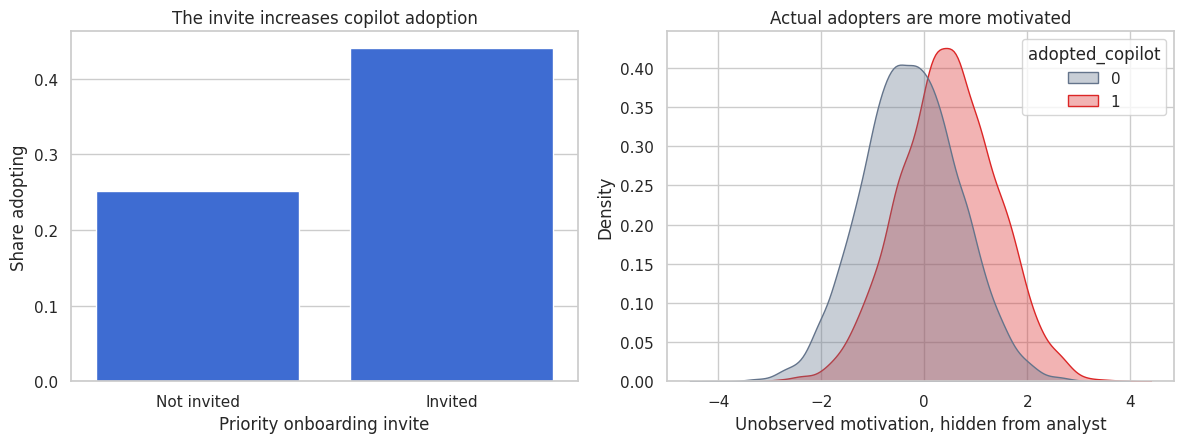

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

takeup = df_enc.groupby("priority_invite")["adopted_copilot"].mean().reset_index()
sns.barplot(data=takeup, x="priority_invite", y="adopted_copilot", color="#2563eb", ax=axes[0])
axes[0].set_title("The invite increases copilot adoption")
axes[0].set_xlabel("Priority onboarding invite")
axes[0].set_ylabel("Share adopting")
axes[0].set_xticklabels(["Not invited", "Invited"])

sns.kdeplot(
    data=df_enc,
    x="unobserved_motivation",
    hue="adopted_copilot",
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette=["#64748b", "#dc2626"],
    ax=axes[1],
)
axes[1].set_title("Actual adopters are more motivated")
axes[1].set_xlabel("Unobserved motivation, hidden from analyst")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

This is the tension encouragement designs solve. The offer is randomized, but uptake is selective. The assignment can be analyzed like an experiment; treatment receipt requires IV-style reasoning.

## 4. Check Randomization Balance

Before estimating effects, check whether pre-treatment covariates are balanced by assignment. In a real experiment, this also catches implementation bugs: bad randomization, assignment leakage, eligibility filters applied after randomization, or data joins that dropped one arm.

In [6]:
balance_rows = []
for covariate in controls:
    model = fit_assignment_model(df_enc, covariate, "priority_invite")
    row = coefficient_row(covariate, model, "priority_invite")
    row["mean_not_invited"] = df_enc.loc[df_enc["priority_invite"] == 0, covariate].mean()
    row["mean_invited"] = df_enc.loc[df_enc["priority_invite"] == 1, covariate].mean()
    row["standardized_difference"] = (
        row["mean_invited"] - row["mean_not_invited"]
    ) / df_enc[covariate].std()
    balance_rows.append(row)

balance_table = pd.DataFrame(balance_rows)[
    [
        "estimand_or_model",
        "mean_not_invited",
        "mean_invited",
        "standardized_difference",
        "estimate",
        "p_value",
    ]
]
display(balance_table.round(3))

,estimand_or_model,mean_not_invited,mean_invited,standardized_difference,estimate,p_value
0,account_size,68.100,67.983,-0.003,-0.117,0.843
1,baseline_usage,49.934,49.873,-0.005,-0.061,0.758
2,risk_score,-0.019,-0.020,-0.001,-0.001,0.928
3,enterprise_plan,0.426,0.429,0.006,0.003,0.704


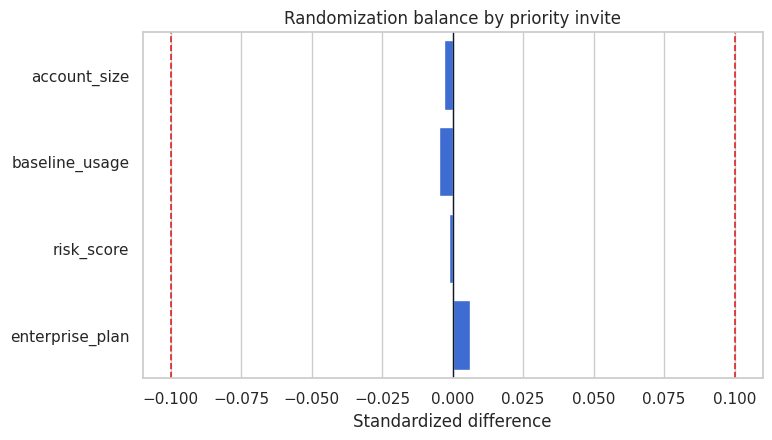

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=balance_table,
    y="estimand_or_model",
    x="standardized_difference",
    color="#2563eb",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#dc2626", linestyle="--", linewidth=1.2)
ax.axvline(-0.10, color="#dc2626", linestyle="--", linewidth=1.2)
ax.set_title("Randomization balance by priority invite")
ax.set_xlabel("Standardized difference")
ax.set_ylabel("")
plt.show()

Balance is about assignment, not uptake. We expect invitation groups to look similar before treatment. We do not expect adopters and non-adopters to look similar.

## 5. Estimate the ITT Effect of Encouragement

The ITT effect answers:

> What is the effect of being invited to priority onboarding?

This is often the most operationally relevant effect. If the business can choose whom to invite, then the invitation effect is directly actionable.

In [8]:
itt_model = fit_assignment_model(df_enc, "renewal_margin", "priority_invite", controls=controls)
itt_table = pd.DataFrame([coefficient_row("ITT: invite -> renewal margin", itt_model, "priority_invite")])
display(itt_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,ITT: invite -> renewal margin,1.539,0.134,1.275,1.802,0.000


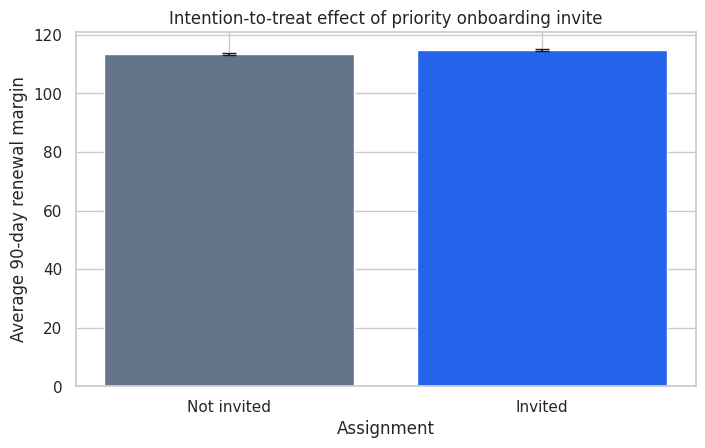

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.6))
assignment_means = (
    df_enc.groupby("priority_invite")
    .agg(avg_margin=("renewal_margin", "mean"), se=("renewal_margin", lambda s: s.std() / np.sqrt(len(s))))
    .reset_index()
)
ax.bar(
    assignment_means["priority_invite"].astype(str),
    assignment_means["avg_margin"],
    yerr=1.96 * assignment_means["se"],
    capsize=5,
    color=["#64748b", "#2563eb"],
)
ax.set_xticklabels(["Not invited", "Invited"])
ax.set_title("Intention-to-treat effect of priority onboarding invite")
ax.set_xlabel("Assignment")
ax.set_ylabel("Average 90-day renewal margin")
plt.show()

The ITT effect is diluted by incomplete uptake. That dilution is not a flaw. It is the real effect of the policy of sending invites under the current product and operations process.

## 6. Estimate the First Stage

The first stage answers:

> How much did the encouragement change actual treatment receipt?

A weak first stage means the encouragement did not meaningfully move behavior. The experiment may still estimate the effect of the invitation, but it will be a poor design for estimating the effect of treatment receipt.

In [10]:
first_stage_model = fit_assignment_model(df_enc, "adopted_copilot", "priority_invite", controls=controls)
first_stage_effect = first_stage_model.params["priority_invite"]
first_stage_f = float(first_stage_model.tvalues["priority_invite"] ** 2)
first_stage_table = pd.DataFrame([coefficient_row("First stage: invite -> adoption", first_stage_model, "priority_invite")])
display(first_stage_table.round(3))
print(f"First-stage robust F-statistic: {first_stage_f:.1f}")

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,First stage: invite -> adoption,0.189,0.008,0.174,0.203,0.000


First-stage robust F-statistic: 622.6


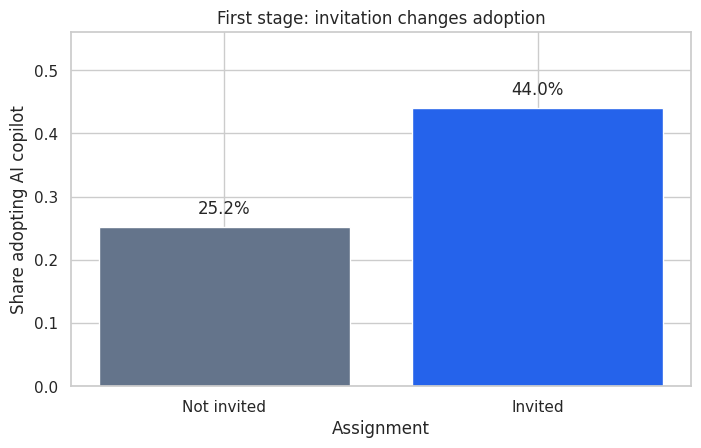

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(
    takeup["priority_invite"].astype(str),
    takeup["adopted_copilot"],
    color=["#64748b", "#2563eb"],
)
ax.set_xticklabels(["Not invited", "Invited"])
ax.set_ylim(0, max(takeup["adopted_copilot"]) + 0.12)
ax.set_title("First stage: invitation changes adoption")
ax.set_xlabel("Assignment")
ax.set_ylabel("Share adopting AI copilot")
for i, value in enumerate(takeup["adopted_copilot"]):
    ax.text(i, value + 0.015, f"{value:.1%}", ha="center", va="bottom")
plt.show()

The first stage is the design's mechanical leverage. Better onboarding copy, better timing, fewer setup steps, or a more valuable offer can all strengthen the first stage.

## 7. CACE: Effect for Invitation-Movable Accounts

The CACE answers:

> Among accounts whose adoption was changed by the priority invite, what was the effect of adopting the AI copilot?

For a binary encouragement and binary treatment, the simple Wald ratio is:

$$
\widehat{CACE} = \frac{\widehat{ITT}_Y}{\widehat{ITT}_D}
$$

This estimand is local to compliers. It is not automatically the effect for never-takers, always-takers, or all accounts.

In [12]:
wald = wald_estimator(df_enc, "renewal_margin", "adopted_copilot", "priority_invite")
controlled_reduced_form = fit_assignment_model(df_enc, "renewal_margin", "priority_invite", controls=controls)
controlled_first_stage = fit_assignment_model(df_enc, "adopted_copilot", "priority_invite", controls=controls)
controlled_cace = controlled_reduced_form.params["priority_invite"] / controlled_first_stage.params["priority_invite"]

wald_table = pd.DataFrame(
    {
        "quantity": ["Unadjusted ITT outcome", "Unadjusted first stage", "Unadjusted CACE", "Controlled CACE"],
        "value": [wald["itt_outcome"], wald["first_stage"], wald["cace"], controlled_cace],
    }
)
display(wald_table.round(3))

,quantity,value
0,Unadjusted ITT outcome,1.515
1,Unadjusted first stage,0.189
2,Unadjusted CACE,8.030
3,Controlled CACE,8.161


In [13]:
iv_result = fit_iv2sls(
    df_enc,
    outcome="renewal_margin",
    treatment="adopted_copilot",
    assignment="priority_invite",
    controls=controls,
)

iv_table = pd.DataFrame([iv_row("2SLS CACE with robust SE", iv_result, "adopted_copilot")])
display(iv_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,2SLS CACE with robust SE,8.161,0.557,7.068,9.253,0.000


The 2SLS result is the same idea as the controlled Wald ratio, with correct IV standard errors. In this simulated example, the true complier effect is known, so we can compare the estimators directly.

In [14]:
true_ate = df_enc["true_effect"].mean()
true_cace = df_enc.loc[df_enc["principal_stratum"] == "complier", "true_effect"].mean()
true_att = df_enc.loc[df_enc["adopted_copilot"] == 1, "true_effect"].mean()

truth_table = pd.DataFrame(
    {
        "target": ["True ATE", "True CACE among compliers", "True ATT among adopters"],
        "value": [true_ate, true_cace, true_att],
    }
)
display(truth_table.round(3))

,target,value
0,True ATE,8.428
1,True CACE among compliers,8.444
2,True ATT among adopters,8.476


In real data, the true CACE is unknown. The point of the simulation is to show why the IV estimand should be compared to the complier effect rather than to the naive adopter effect.

## 8. Why As-Treated Comparisons Are Biased

A common mistake is to compare adopters to non-adopters after the experiment. That abandons the randomization. Adopters are more motivated and more likely to renew even without the product.

We compare several estimators below.

In [15]:
naive_as_treated = (
    df_enc.loc[df_enc["adopted_copilot"] == 1, "renewal_margin"].mean()
    - df_enc.loc[df_enc["adopted_copilot"] == 0, "renewal_margin"].mean()
)

ols_adoption = fit_ols(df_enc, "renewal_margin", "adopted_copilot", controls=controls)

comparison_table = pd.DataFrame(
    [
        {"estimand_or_model": "Naive as-treated difference", "estimate": naive_as_treated, "std_error": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan},
        coefficient_row("OLS on adoption with controls", ols_adoption, "adopted_copilot"),
        coefficient_row("ITT invite effect", ittt_model if False else itt_model, "priority_invite"),
        iv_row("2SLS CACE", iv_result, "adopted_copilot"),
        {"estimand_or_model": "True CACE in simulation", "estimate": true_cace, "std_error": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan},
    ]
)
display(comparison_table.round(3))

,estimand_or_model,estimate,std_error,ci_low,ci_high,p_value
0,Naive as-treated difference,13.337,NaN,NaN,NaN,NaN
1,OLS on adoption with controls,11.466,0.109,11.253,11.679,0.000
2,ITT invite effect,1.539,0.134,1.275,1.802,0.000
3,2SLS CACE,8.161,0.557,7.068,9.253,0.000
4,True CACE in simulation,8.444,NaN,NaN,NaN,NaN


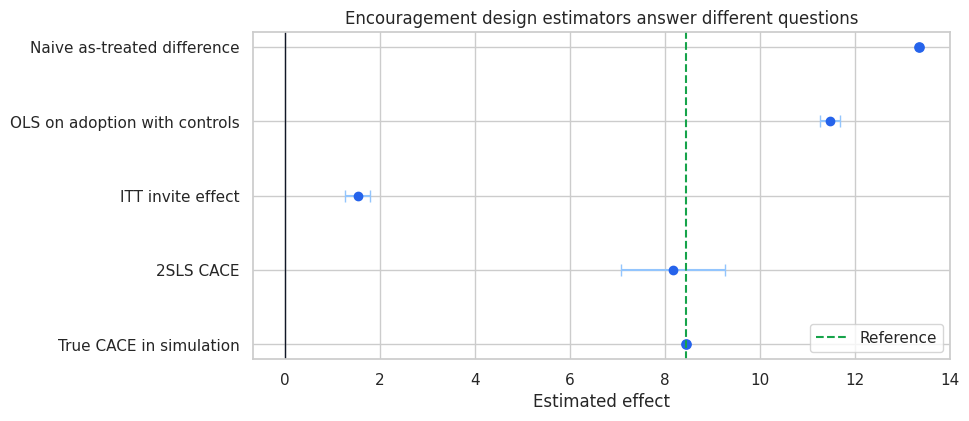

In [16]:
plot_estimate_table(
    comparison_table,
    title="Encouragement design estimators answer different questions",
    reference=true_cace,
)
plt.show()

The ITT is smaller because it is the effect of the invitation policy, not the effect of adoption among those induced to adopt. The as-treated and OLS estimates are larger because adoption is selected on unobserved motivation.

## 9. Principal Strata: Who Is the CACE About?

In an encouragement design, units can be grouped by how they would behave under each assignment:

- Never-takers: do not adopt with or without the invite.
- Always-takers: adopt even without the invite.
- Compliers: adopt if invited, do not adopt if not invited.
- Defiers: adopt if not invited, do not adopt if invited.

The standard monotonicity assumption rules out defiers. In business language, the invite should not make some accounts less likely to adopt.

In [17]:
strata_table = (
    df_enc.groupby("principal_stratum")
    .agg(
        accounts=("account_id", "count"),
        share=("account_id", lambda s: len(s) / len(df_enc)),
        adoption_rate=("adopted_copilot", "mean"),
        avg_true_effect=("true_effect", "mean"),
        avg_motivation=("unobserved_motivation", "mean"),
        avg_margin=("renewal_margin", "mean"),
    )
    .sort_values("share", ascending=False)
)
display(strata_table.round(3))

,accounts,share,adoption_rate,avg_true_effect,avg_motivation,avg_margin
principal_stratum,,,,,,
never-taker,8341,0.556,0.000,8.397,-0.342,108.966
always-taker,3801,0.253,1.000,8.481,0.551,123.422
complier,2858,0.191,0.486,8.444,0.187,116.943


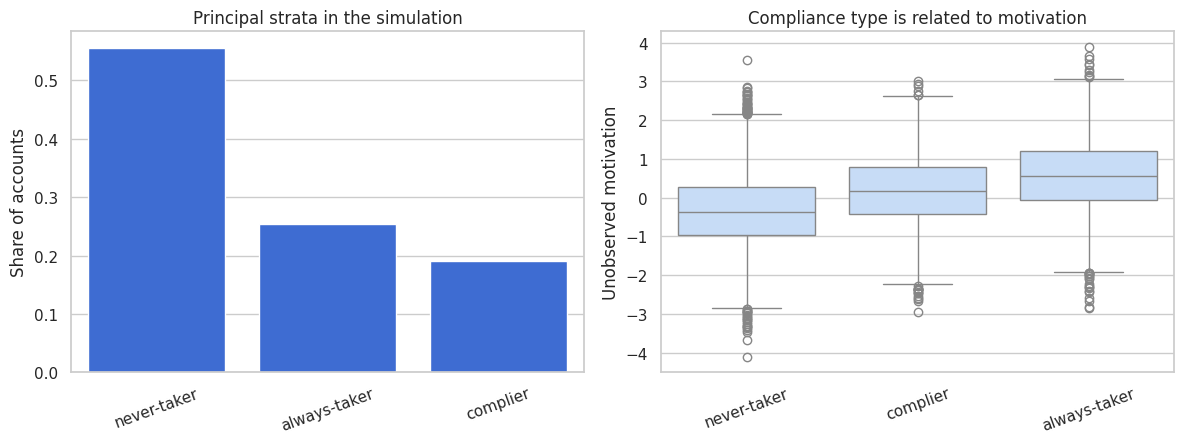

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

strata_plot = strata_table.reset_index()
sns.barplot(data=strata_plot, x="principal_stratum", y="share", color="#2563eb", ax=axes[0])
axes[0].set_title("Principal strata in the simulation")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of accounts")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df_enc,
    x="principal_stratum",
    y="unobserved_motivation",
    color="#bfdbfe",
    ax=axes[1],
)
axes[1].set_title("Compliance type is related to motivation")
axes[1].set_xlabel("")
axes[1].set_ylabel("Unobserved motivation")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

We can see principal strata only because this is simulated data. In real experiments, each account is observed under one assignment. The compliance-strata interpretation is a conceptual tool, not a directly observed label.

## 10. Design Strength and Precision

Encouragement strength is a design lever. If the encouragement barely changes uptake, the first stage is weak and the CACE estimate becomes noisy. If the encouragement changes uptake a lot, the CACE estimate is more precise.

This is why encouragement design is partly a product-design problem. The nudge must be strong enough to move behavior while still satisfying exclusion.

In [19]:
strength_rows = []
for strength in [0.20, 0.40, 0.70, 1.00, 1.30, 1.60]:
    simulated = simulate_encouragement_data(encouragement_strength=strength, seed=7707)
    fs = fit_assignment_model(simulated, "adopted_copilot", "priority_invite", controls=controls)
    iv = fit_iv2sls(simulated, "renewal_margin", "adopted_copilot", "priority_invite", controls=controls)
    row = iv_row(f"strength = {strength:.2f}", iv, "adopted_copilot")
    row["strength"] = strength
    row["first_stage"] = float(fs.params["priority_invite"])
    row["first_stage_F"] = float(fs.tvalues["priority_invite"] ** 2)
    row["adoption_without_invite"] = simulated.loc[simulated["priority_invite"] == 0, "adopted_copilot"].mean()
    row["adoption_with_invite"] = simulated.loc[simulated["priority_invite"] == 1, "adopted_copilot"].mean()
    strength_rows.append(row)

strength_table = pd.DataFrame(strength_rows)
display(
    strength_table[
        [
            "strength",
            "adoption_without_invite",
            "adoption_with_invite",
            "first_stage",
            "first_stage_F",
            "estimate",
            "std_error",
            "ci_low",
            "ci_high",
        ]
    ].round(3)
)

,strength,adoption_without_invite,adoption_with_invite,first_stage,first_stage_F,estimate,std_error,ci_low,ci_high
0,0.200,0.252,0.290,0.038,28.331,7.016,2.799,1.530,12.502
1,0.400,0.252,0.325,0.074,101.224,7.704,1.438,4.887,10.522
2,0.700,0.252,0.382,0.130,305.189,8.042,0.807,6.460,9.624
3,1.000,0.252,0.440,0.189,622.573,8.161,0.557,7.068,9.253
4,1.300,0.252,0.499,0.248,1065.119,8.229,0.424,7.398,9.060
5,1.600,0.252,0.565,0.313,1715.424,8.265,0.335,7.608,8.922


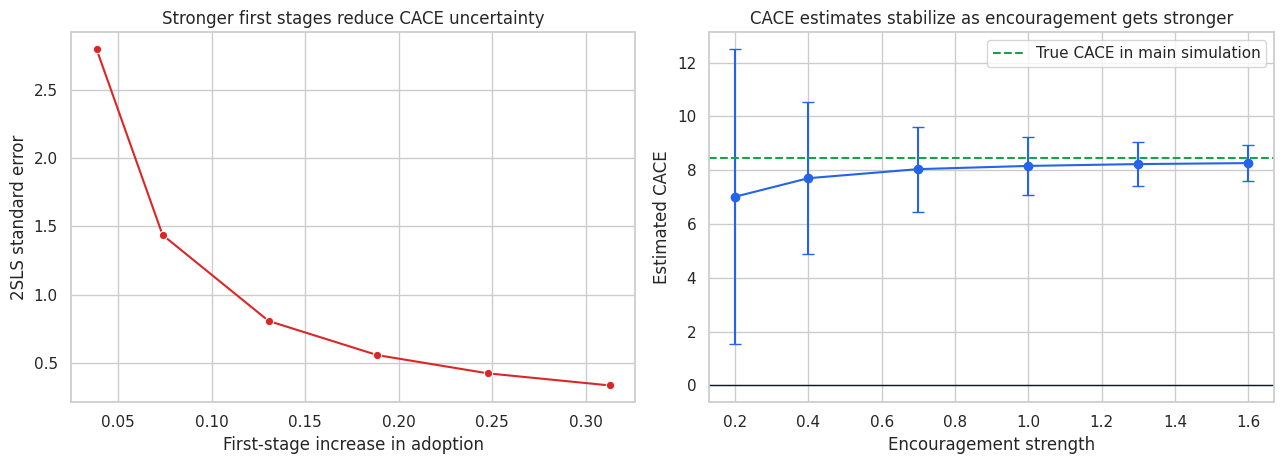

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.lineplot(
    data=strength_table,
    x="first_stage",
    y="std_error",
    marker="o",
    color="#dc2626",
    ax=axes[0],
)
axes[0].set_title("Stronger first stages reduce CACE uncertainty")
axes[0].set_xlabel("First-stage increase in adoption")
axes[0].set_ylabel("2SLS standard error")

axes[1].errorbar(
    strength_table["strength"],
    strength_table["estimate"],
    yerr=1.96 * strength_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#2563eb",
)
axes[1].axhline(true_cace, color="#16a34a", linestyle="--", linewidth=1.5, label="True CACE in main simulation")
axes[1].axhline(0, color="#111827", linewidth=1)
axes[1].set_title("CACE estimates stabilize as encouragement gets stronger")
axes[1].set_xlabel("Encouragement strength")
axes[1].set_ylabel("Estimated CACE")
axes[1].legend()

plt.tight_layout()
plt.show()

A weak encouragement can still be a useful A/B test of the encouragement itself, but it is a weak instrument for treatment receipt.

## 11. Exclusion Restriction: The Trap in Better Encouragements

A stronger encouragement is not always better. If the invitation itself directly affects the outcome, exclusion fails.

For example, suppose the priority onboarding invite includes a relationship-building call, a one-time discount, or escalation support that can improve renewal even if the account never adopts the AI copilot. Then the invite affects renewal through a path other than adoption.

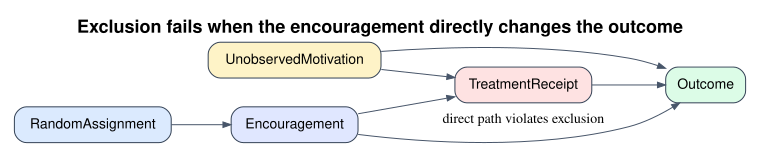

In [21]:
make_dag(
    edges=[
        ("RandomAssignment", "Encouragement"),
        ("Encouragement", "TreatmentReceipt"),
        ("TreatmentReceipt", "Outcome"),
        ("Encouragement", "Outcome", "direct path violates exclusion"),
        ("UnobservedMotivation", "TreatmentReceipt"),
        ("UnobservedMotivation", "Outcome"),
    ],
    title="Exclusion fails when the encouragement directly changes the outcome",
    node_colors={
        "RandomAssignment": "#dbeafe",
        "Encouragement": "#e0e7ff",
        "TreatmentReceipt": "#fee2e2",
        "Outcome": "#dcfce7",
        "UnobservedMotivation": "#fef3c7",
    },
)

In [22]:
exclusion_rows = []
for direct_effect in [0.0, 0.5, 1.0, 2.0, 3.0]:
    simulated = simulate_encouragement_data(direct_offer_effect=direct_effect, seed=7707)
    iv = fit_iv2sls(simulated, "renewal_margin", "adopted_copilot", "priority_invite", controls=controls)
    itt = fit_assignment_model(simulated, "renewal_margin", "priority_invite", controls=controls)
    fs = fit_assignment_model(simulated, "adopted_copilot", "priority_invite", controls=controls)
    row = iv_row(f"direct offer effect = {direct_effect:.1f}", iv, "adopted_copilot")
    row["direct_offer_effect"] = direct_effect
    row["itt_outcome"] = float(itt.params["priority_invite"])
    row["first_stage"] = float(fs.params["priority_invite"])
    exclusion_rows.append(row)

exclusion_table = pd.DataFrame(exclusion_rows)
display(
    exclusion_table[
        ["direct_offer_effect", "itt_outcome", "first_stage", "estimate", "std_error", "ci_low", "ci_high"]
    ].round(3)
)

,direct_offer_effect,itt_outcome,first_stage,estimate,std_error,ci_low,ci_high
0,0.000,1.539,0.189,8.161,0.557,7.068,9.253
1,0.500,2.039,0.189,10.812,0.541,9.752,11.873
2,1.000,2.539,0.189,13.464,0.545,12.395,14.532
3,2.000,3.539,0.189,18.767,0.612,17.568,19.966
4,3.000,4.539,0.189,24.070,0.736,22.628,25.512


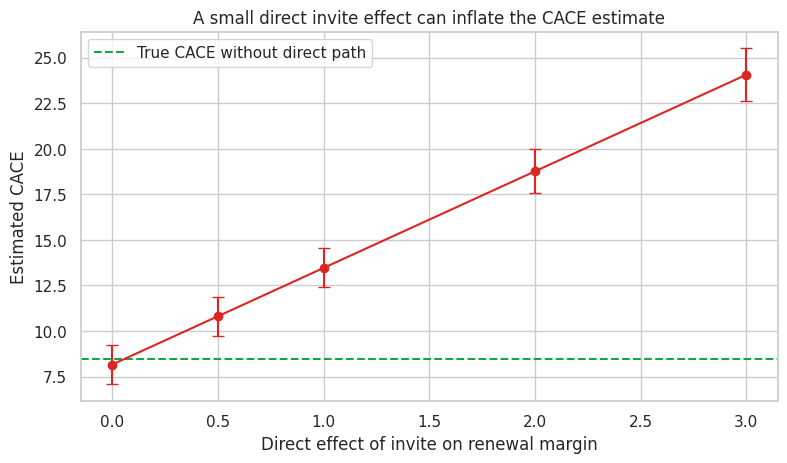

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    exclusion_table["direct_offer_effect"],
    exclusion_table["estimate"],
    yerr=1.96 * exclusion_table["std_error"],
    fmt="o-",
    capsize=4,
    color="#dc2626",
)
ax.axhline(true_cace, color="#16a34a", linestyle="--", linewidth=1.5, label="True CACE without direct path")
ax.set_title("A small direct invite effect can inflate the CACE estimate")
ax.set_xlabel("Direct effect of invite on renewal margin")
ax.set_ylabel("Estimated CACE")
ax.legend()
plt.show()

The direct invite effect is divided by the first stage, so even a modest exclusion violation can create a large bias in CACE. This is the most important design lesson: make the encouragement move treatment, but avoid making it a bundle of other treatments.

## 12. One-Sided Versus Two-Sided Noncompliance

Encouragement designs come in two common forms.

One-sided noncompliance:

- Only encouraged units can receive treatment.
- Some encouraged units decline.
- Unencouraged units cannot receive treatment.
- Example: a private beta invitation where only invited users can access the feature.

Two-sided noncompliance:

- Encouraged units are more likely to receive treatment.
- Unencouraged units can still receive treatment through other channels.
- Example: priority onboarding invite, but motivated accounts can self-serve.

Two-sided noncompliance is common in product and marketplace settings. It is not fatal, but it makes the compliance story more important.

In [24]:
one_sided = df_enc.copy()
one_sided["adopted_if_one_sided"] = np.where(one_sided["priority_invite"] == 1, one_sided["d1_with_invite"], 0)

two_sided_rates = df_enc.groupby("priority_invite")["adopted_copilot"].mean()
one_sided_rates = one_sided.groupby("priority_invite")["adopted_if_one_sided"].mean()

noncompliance_table = pd.DataFrame(
    {
        "assignment": ["Not invited", "Invited"],
        "two_sided_adoption_rate": [two_sided_rates.loc[0], two_sided_rates.loc[1]],
        "one_sided_adoption_rate": [one_sided_rates.loc[0], one_sided_rates.loc[1]],
    }
)
display(noncompliance_table.round(3))

,assignment,two_sided_adoption_rate,one_sided_adoption_rate
0,Not invited,0.252,0.000
1,Invited,0.440,0.440


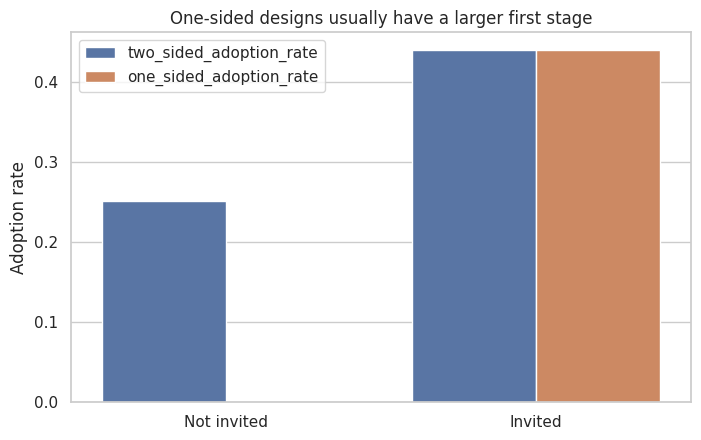

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_rates = noncompliance_table.melt(
    id_vars="assignment",
    value_vars=["two_sided_adoption_rate", "one_sided_adoption_rate"],
    var_name="design",
    value_name="adoption_rate",
)
sns.barplot(data=plot_rates, x="assignment", y="adoption_rate", hue="design", ax=ax)
ax.set_title("One-sided designs usually have a larger first stage")
ax.set_xlabel("")
ax.set_ylabel("Adoption rate")
ax.legend(title="")
plt.show()

When possible, one-sided access can simplify interpretation. In many industry settings it is not possible because customers can discover the product, sellers can self-enroll, or teams can route around the assignment.

## 13. Practical Design Checklist

Before launching an encouragement experiment, write down the design in operational terms.

**Eligibility**: who can be assigned?

**Assignment**: what is randomized, and at what unit of randomization?

**Encouragement**: what exactly changes for encouraged units?

**Treatment receipt**: what behavior counts as actual treatment?

**Outcome window**: when is the outcome measured?

**First-stage target**: how much uptake lift is needed for the CACE estimate to be useful?

**Exclusion story**: why should the encouragement affect the outcome only through treatment receipt?

**Interference risk**: can encouraged units affect unencouraged units?

**Monitoring**: are there assignment leaks, override paths, or operational exceptions?

## 14. Industry Readout Template

A good readout reports both the policy effect and the treatment-receipt effect. The ITT answers whether the encouragement should be used. The CACE answers what treatment does for invitation-movable accounts.

In [26]:
readout = pd.DataFrame(
    {
        "item": [
            "Business question",
            "Randomized assignment",
            "Treatment receipt",
            "Outcome",
            "ITT effect of invite",
            "First stage",
            "2SLS CACE",
            "95% CI for CACE",
            "First-stage F-statistic",
            "Complier interpretation",
            "Main threat",
            "Decision implication",
        ],
        "value": [
            "Does adopting AI copilot improve renewal margin?",
            "Priority onboarding invite",
            "Adopted AI copilot workflow",
            "90-day renewal margin",
            f"{itt_model.params['priority_invite']:.3f}",
            f"{first_stage_effect:.3f} adoption-rate increase",
            f"{iv_result.params['adopted_copilot']:.3f}",
            f"[{iv_result.conf_int().loc['adopted_copilot'].iloc[0]:.3f}, {iv_result.conf_int().loc['adopted_copilot'].iloc[1]:.3f}]",
            f"{first_stage_f:.1f}",
            "Accounts whose adoption was changed by the priority invite",
            "Exclusion: invite must not improve renewal except through copilot adoption",
            "Use ITT for invite policy decisions; use CACE for adoption-value sizing among movable accounts.",
        ],
    }
)
display(readout)

,item,value
0,Business question,Does adopting AI copilot improve renewal margin?
1,Randomized assignment,Priority onboarding invite
2,Treatment receipt,Adopted AI copilot workflow
3,Outcome,90-day renewal margin
4,ITT effect of invite,1.539
5,First stage,0.189 adoption-rate increase
6,2SLS CACE,8.161
7,95% CI for CACE,"[7.068, 9.253]"
8,First-stage F-statistic,622.6
9,Complier interpretation,Accounts whose adoption was changed by the pri...


## Key Takeaways

- Encouragement designs randomize a push toward treatment rather than treatment itself.
- The ITT effect of encouragement is always an experiment-based estimate of the assignment policy.
- The CACE estimate requires the IV assumptions: relevance, independence, exclusion, and monotonicity.
- CACE applies to compliers: units whose treatment receipt changed because of the encouragement.
- As-treated comparisons discard randomization and are usually biased.
- Stronger encouragement improves precision only if it does not introduce direct outcome paths.
- In industry, encouragement designs are practical because invitations, reminders, priority slots, subsidies, and onboarding support are often easier to randomize than product adoption itself.

## References

Agniel, D., Cefalu, M., Han, B., et al. (2021). Synthetic estimation for the complier average causal effect. *Canadian Journal of Statistics, 50*(2), 592-611. https://doi.org/10.1002/cjs.11634

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. https://doi.org/10.1080/01621459.1996.10476902

Behaghel, L., Crepon, B., & Gurgand, M. (2013). Robustness of the encouragement design in a two-treatment randomized control trial. *SSRN Electronic Journal*. https://doi.org/10.2139/ssrn.2283562

Bloom, H. S. (1984). Accounting for no-shows in experimental evaluation designs. *Evaluation Review, 8*(2), 225-246. https://doi.org/10.1177/0193841x8400800205

Homer, C. (2002). Using the Zelen design in randomized controlled trials: Debates and controversies. *Journal of Advanced Nursing, 38*(2), 200-207. https://doi.org/10.1046/j.1365-2648.2002.02164.x

Imbens, G. W., & Angrist, J. D. (1994). Identification and estimation of local average treatment effects. *Econometrica, 62*(2), 467-475. https://doi.org/10.2307/2951620

Rudolph, K. E., & van der Laan, M. J. (2016). Robust estimation of encouragement design intervention effects transported across sites. *Journal of the Royal Statistical Society: Series B, 79*(5), 1509-1525. https://doi.org/10.1111/rssb.12213

Simon, G. E., Shortreed, S. M., & DeBar, L. (2021). Zelen design clinical trials: Why, when, and how. *Trials, 22*, 541. https://doi.org/10.1186/s13063-021-05517-w